# Delhi AQI & Weather - Full ML Lifecycle

This notebook merges the previous approach with the specific modeling criteria, Label Encoding, `aqi_index` targets, and Gradient Boosting hyperparameters you tested in your custom notebook!

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from xgboost import XGBRegressor, XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="darkgrid")

## 1. Data Ingestion

In [3]:
# Load original dataset from the root directory
df = pd.read_csv('delhi-weather-aqi-2025.csv')

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (52560, 16)


,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


## 2. Exploratory Data Analysis (EDA)

Missing Values:
 Series([], dtype: int64)


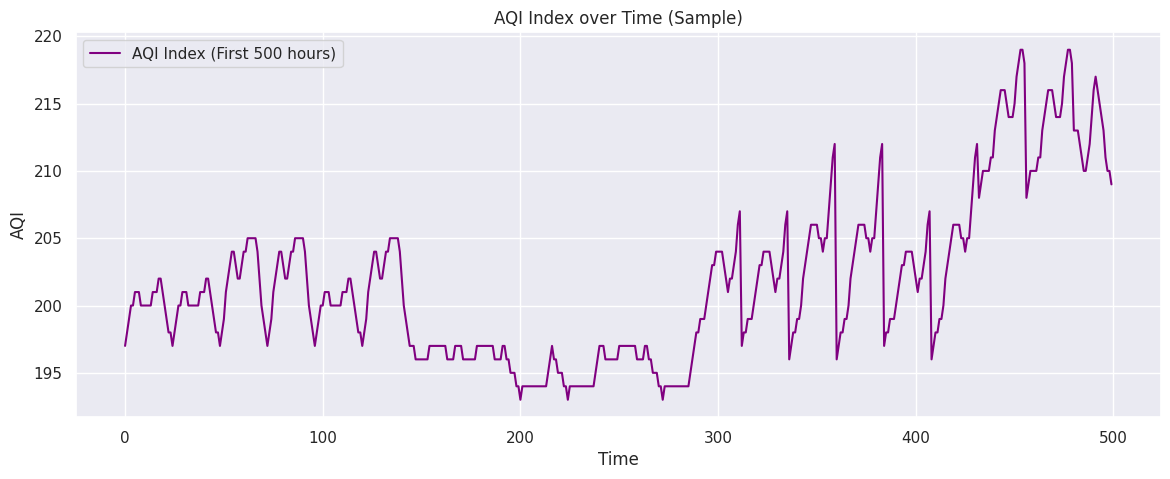

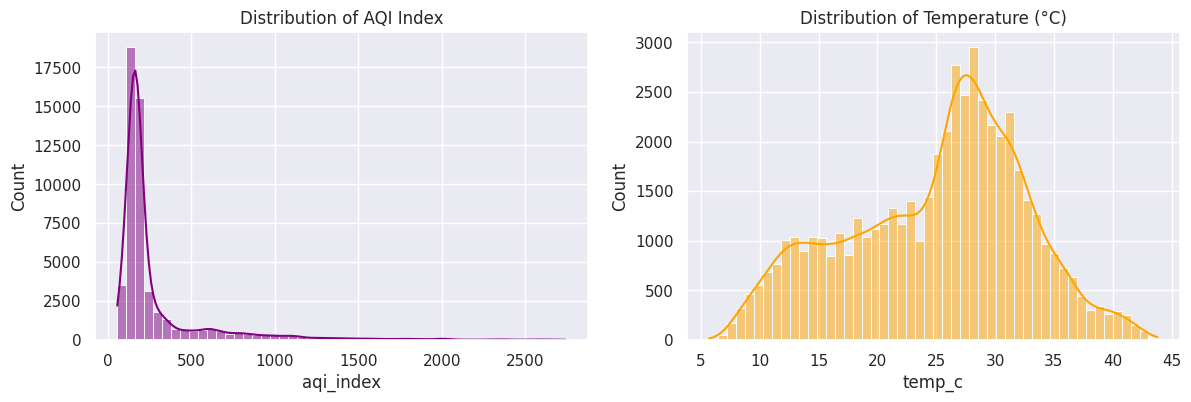

In [4]:
# Check for missing values
missing_data = df.isnull().sum()
print("Missing Values:\n", missing_data[missing_data > 0])

# Time-Series Plot of AQI Index
plt.figure(figsize=(14, 5))
plt.plot(df['aqi_index'].values[:500], label='AQI Index (First 500 hours)', color='purple')
plt.title('AQI Index over Time (Sample)')
plt.xlabel('Time')
plt.ylabel('AQI')
plt.legend()
plt.show()

# Distribution of Target Variables
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['aqi_index'], bins=50, kde=True, ax=ax[0], color='purple')
ax[0].set_title('Distribution of AQI Index')

sns.histplot(df['temp_c'], bins=50, kde=True, ax=ax[1], color='orange')
ax[1].set_title('Distribution of Temperature (°C)')
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [5]:
# 1. Label Encoding Categorical Variables
# Applying the same LabelEncoding technique you used for non-numeric columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Exclude datetime columns from general label encoding
categorical_cols = [col for col in categorical_cols if col not in ['date_ist', 'time_ist']]

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"Encoded {col}: {le.classes_}")

# 2. Extract Temporal Features instead of dropping completely
df['datetime'] = pd.to_datetime(df['date_ist'] + ' ' + df['time_ist'], format='%d/%m/%Y %H:%M')
df = df.sort_values('datetime').reset_index(drop=True)

df['Hour'] = df['datetime'].dt.hour
df['Day'] = df['datetime'].dt.day
df['Month'] = df['datetime'].dt.month

df = df.drop(['date_ist', 'time_ist', 'datetime'], axis=1)

# 3. Impute missing values with median (as implemented in your notebook)
for col in df.columns:
    df[col].fillna(df[col].median(), inplace=True)

# 4. Filter by Correlation (Optional feature selection you added)
# Ensure we only use highly correlated features as you specified
corr_matrix = df.corr()
relates = corr_matrix['aqi_index']
attributes = [df.columns[i] for i in range(len(relates)) if relates.iloc[i] > 0.01]
print(f"\nFeatures with positive correlation > 0.01 selected: {attributes}")

df_clean = df[attributes]

print(f"Shape after Preprocessing: {df_clean.shape}")

# Define Target and Features (Predicting aqi_index instead of pm2_5)
X = df_clean.drop(columns=['aqi_index'])
y_reg = df_clean['aqi_index']

# Split data (You used 70% random sampling, here we use train_test_split for consistency)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Encoded location: ['Anand Vihar' 'Connaught Place' 'Dwarka' 'IGI Airport' 'Okhla Phase III'
 'Rohini']
Encoded condition_text: ['Clear sky' 'Drizzle: Dense' 'Drizzle: Light' 'Drizzle: Moderate' 'Fog'
 'Mainly clear' 'Overcast' 'Partly cloudy' 'Rain: Heavy' 'Rain: Moderate'
 'Rain: Slight']
Encoded description: ['WMO Code 0' 'WMO Code 1' 'WMO Code 2' 'WMO Code 3' 'WMO Code 45'
 'WMO Code 51' 'WMO Code 53' 'WMO Code 55' 'WMO Code 61' 'WMO Code 63'
 'WMO Code 65']

Features with positive correlation > 0.01 selected: ['location', 'temp_c', 'windspeed_kph', 'aqi_index', 'pm2_5', 'pm10']
Shape after Preprocessing: (52560, 6)


## 4. Part A: Classification Modeling (AQI Categories)


Training Logistic Regression...
Accuracy:  0.8215
Precision: 0.8208
Recall:    0.8215
F1 Score:  0.8124


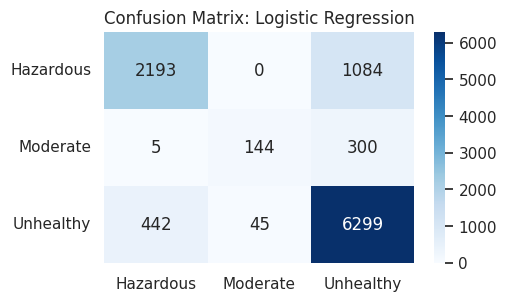


Training Random Forest (Ensemble)...
Accuracy:  0.9224
Precision: 0.9223
Recall:    0.9224
F1 Score:  0.9217


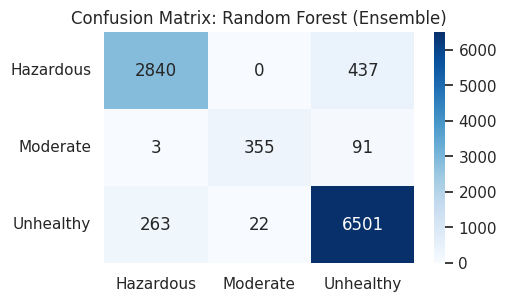

In [6]:
# Define bins based on your Notebook's AQI thresholds
# <= 50 Good, <= 100 Moderate, <= 200 Unhealthy, else Hazardous
def categorize_aqi(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 200: return "Unhealthy"
    else: return "Hazardous"

y_class = df_clean['aqi_index'].apply(categorize_aqi)

y_train_cls, y_test_cls = train_test_split(y_class, test_size=0.2, random_state=42)

# Encode class labels
le_target = LabelEncoder()
y_train_cls_encoded = le_target.fit_transform(y_train_cls)
y_test_cls_encoded = le_target.transform(y_test_cls)

# Train Models
models_cls = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models_cls.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train_cls)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test_cls, y_pred)
    prec = precision_score(y_test_cls, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_cls, y_pred, average='weighted')
    f1 = f1_score(y_test_cls, y_pred, average='weighted')

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test_cls, y_pred, labels=model.classes_)
    plt.figure(figsize=(5,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

## 5. Part B: Regression Modeling (Exact AQI Prediction)



Training Linear Regression...
RMSE:     182.9045
MAE:      92.9218
R2 Score: 0.7021

Training Ridge Regression...
RMSE:     182.9047
MAE:      92.9222
R2 Score: 0.7021

Training Lasso Regression...
RMSE:     182.9091
MAE:      92.9165
R2 Score: 0.7021

Training Decision Tree...
RMSE:     134.8486
MAE:      39.7217
R2 Score: 0.8381

Training K-Nearest Neighbors...
RMSE:     159.2479
MAE:      74.4162
R2 Score: 0.7742

Training Gradient Boosting...
RMSE:     122.7852
MAE:      60.9102
R2 Score: 0.8657


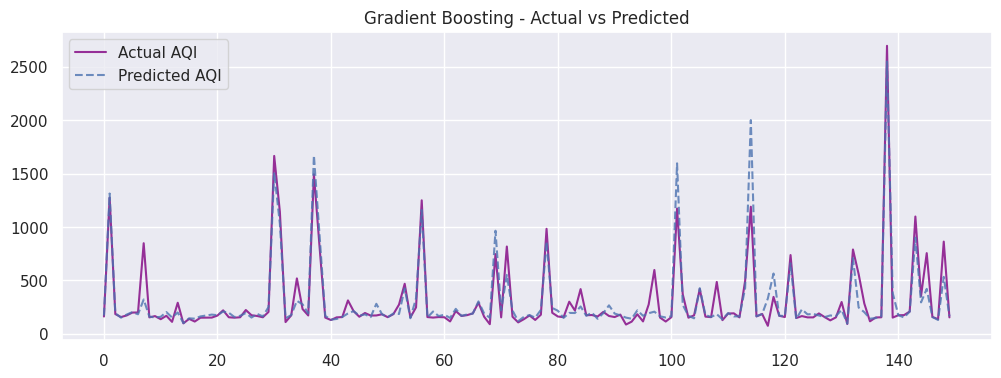


Training Random Forest Regressor...
RMSE:     100.7455
MAE:      43.7646
R2 Score: 0.9096

Training XGBoost Regressor...
RMSE:     132.0307
MAE:      65.3623
R2 Score: 0.8448


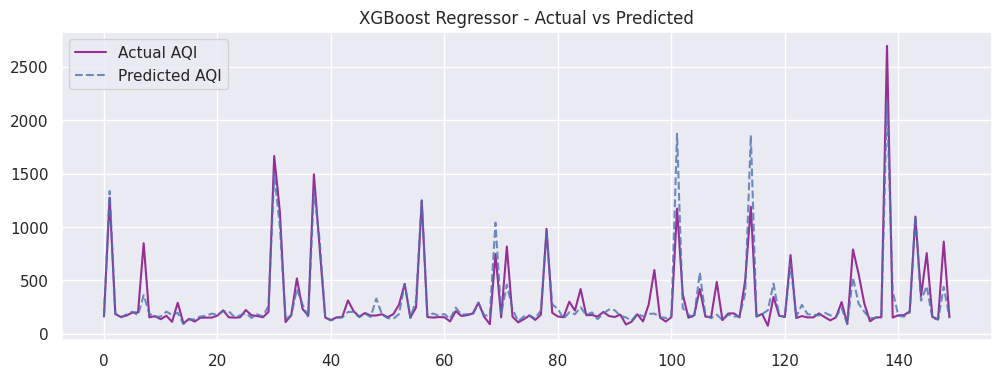

In [11]:
# User's tuned parameters for Gradient Boosting
gb_params = {
    "n_estimators": 1000,
    "max_depth": 8,
    "min_samples_split": 6,
    "learning_rate": 0.01,
    "loss": "squared_error"
}

models_reg = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Gradient Boosting": GradientBoostingRegressor(**gb_params),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
}

for name, model in models_reg.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train_reg)
    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)

    print(f"RMSE:     {rmse:.4f}")
    print(f"MAE:      {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")

    # Plot true vs predicted for the best models
    if "XGBoost" in name or "Gradient Boosting" in name:
        plt.figure(figsize=(12,4))
        plt.plot(y_test_reg.values[:150], label='Actual AQI', alpha=0.8, color='purple')
        plt.plot(y_pred[:150], label='Predicted AQI', alpha=0.8, linestyle='--')
        plt.title(f'{name} - Actual vs Predicted')
        plt.legend()
        plt.show()

## 6. Feature Importance\n\nLet's visualize which weather and temporal features have the most impact on determining the exact AQI.

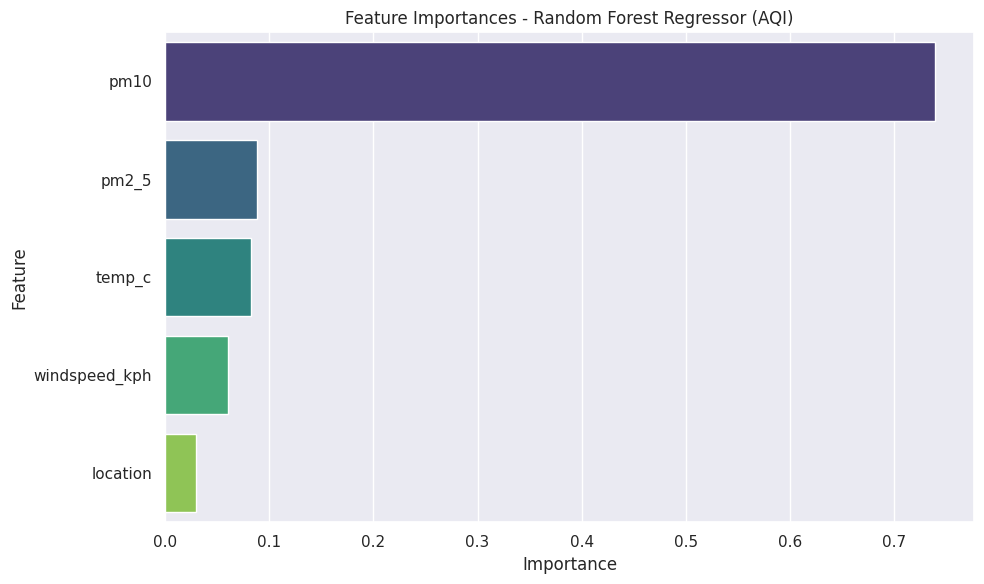

In [12]:
# Extract the best performing Regression Model (Random Forest)
rf_best_model = models_reg["Random Forest Regressor"]

# Get feature names from DataFrame
feature_names = X.columns
importances = rf_best_model.feature_importances_

# Create a DataFrame
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Feature Importances - Random Forest Regressor (AQI)')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning\n\nUsing RandomizedSearchCV to fine-tune the Random Forest Regressor to squeeze out more performance.

Starting Randomized Search for Random Forest Regressor...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  10.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   4.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   3.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   7.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   6.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   6.9s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   6.1s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   6.8s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=

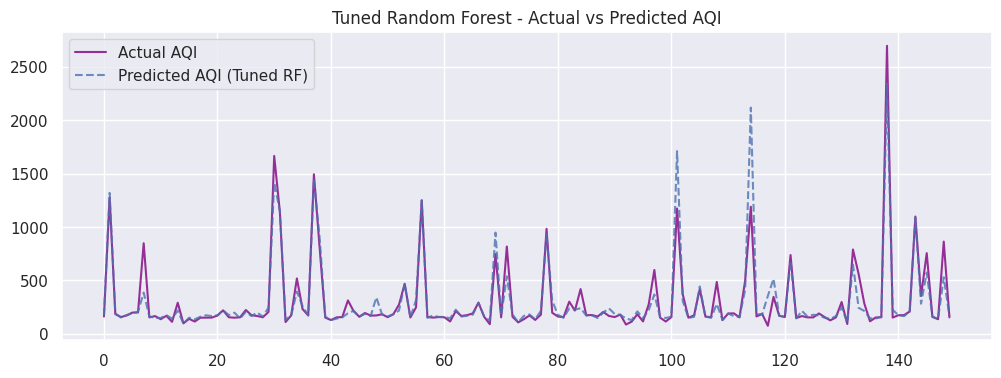

In [14]:
from sklearn.model_selection import RandomizedSearchCV

# Define a much smaller parameter grid for speed
param_distributions = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize the model
rf = RandomForestRegressor(random_state=42)

# Set up RandomizedSearchCV (n_jobs=1 to prevent Windows kernel hanging issues)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                               n_iter=5, cv=3, verbose=2, random_state=42, n_jobs=1, scoring='neg_root_mean_squared_error')

print("Starting Randomized Search for Random Forest Regressor...")
rf_random.fit(X_train_scaled, y_train_reg)

print(f"\nBest Parameters: {rf_random.best_params_}")
best_rf = rf_random.best_estimator_

# Evaluate the tuned model
y_pred_tuned = best_rf.predict(X_test_scaled)
rmse_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned))
r2_tuned = r2_score(y_test_reg, y_pred_tuned)

print(f"Tuned RMSE: {rmse_tuned:.4f}")
print(f"Tuned R2 Score: {r2_tuned:.4f}")

# Plotting Tuned vs Actual
plt.figure(figsize=(12,4))
plt.plot(y_test_reg.values[:150], label='Actual AQI', alpha=0.8, color='purple')
plt.plot(y_pred_tuned[:150], label='Predicted AQI (Tuned RF)', alpha=0.8, linestyle='--')
plt.title('Tuned Random Forest - Actual vs Predicted AQI')
plt.legend()
plt.show()


## 8. Stratified K-Fold Cross-Validation (Classification)

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

# Initialize the Random Forest Classifier
rf_clf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

# Create a pipeline that scales data strictly within each fold
pipeline = make_pipeline(StandardScaler(), rf_clf_cv)

# Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running Stratified K-Fold CV (5 splits) for Random Forest Classifier...")

cv_scores = cross_val_score(pipeline, X, y_class, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"\nStratified CV Accuracy per fold: {cv_scores}")
print(f"Mean Stratified CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


Running Stratified K-Fold CV (5 splits) for Random Forest Classifier...

Stratified CV Accuracy per fold: [0.92218417 0.91647641 0.92636986 0.92123288 0.92199391]
Mean Stratified CV Accuracy: 0.9217
Standard Deviation: 0.0032


## 9. Save Models for Deployment\n\nLet's export all our trained components (The tuned Random Forest Regressor, the Random Forest Classifier, the standard scaler, and the categorical encoders) using `joblib` so we can easily load them into a web app later!

In [16]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# 1. Save Scaling Parameters
joblib.dump(scaler, 'models/scaler.joblib')

# 2. Save Categorical Label Encoders
joblib.dump(le_dict, 'models/le_dict.joblib')

# 3. Save Target Label Encoder (for Classification Targets)
joblib.dump(le_target, 'models/le_target.joblib')

# 4. Save Final Regression Model (Tuned Random Forest)
rf_regressor_to_save = best_rf if 'best_rf' in locals() else models_reg["Random Forest Regressor"]
joblib.dump(rf_regressor_to_save, 'models/rf_regressor.joblib')

# 5. Save Final Classification Model
rf_classifier_to_save = models_cls["Random Forest (Ensemble)"]
joblib.dump(rf_classifier_to_save, 'models/rf_classifier.joblib')

print("✅ All artifacts successfully saved and exported!")
print("Files available in 'models/':", os.listdir('models'))


✅ All artifacts successfully saved and exported!
Files available in 'models/': ['le_target.joblib', 'rf_regressor.joblib', 'le_dict.joblib', 'rf_classifier.joblib', 'scaler.joblib']


In [17]:
import shutil
from google.colab import files

# Compress the 'models' folder into a zip file
shutil.make_archive('exported_models', 'zip', 'models')

# Prompt your browser to download it
files.download('exported_models.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>